### Домашнее задание 15

In [4]:
import time
import matplotlib.pyplot as plt
import numpy as np
import random

### Задача 1. Быстрое возведение чисел в степень

Реализуйте быстрое возведение чисел в степень. Тестировать можно на маленьких числах, например 2. Для отладки рекомендуется выводить все промежуточные шаги, в частности текущий результат и текущий бит двоичного представления показателя степени.

In [2]:
def power(x: int, n: int) -> int:
    curr = x
    binary_n = str(bin(n))[2:]

    for b in binary_n[1:]:
        curr *= curr
        if b == '1':
            curr *= x

    return curr

In [3]:
# tests

for i in range(20):
    x = random.randint(1, 50)
    n = random.randint(1, 50)
    assert power(x, n) == x**n

### Задача 2. Умножение матриц $2 \times 2$

Реализуйте умножение матриц $2 \times 2$ и проверьте его работоспособность, сравнив выход с матричным умножением из библиотеки numpy.

In [95]:
# пусть будет супер просто, вручную практически

def multiply_2x2(matrix1: list, matrix2: list) -> list:
    out = [[0, 0], [0, 0]]

    out[0][0] = matrix1[0][0] * matrix2[0][0] + matrix1[0][1] * matrix2[1][0]
    out[0][1] = matrix1[0][0] * matrix2[0][1] + matrix1[0][1] * matrix2[1][1]
    out[1][0] = matrix1[1][0] * matrix2[0][0] + matrix1[1][1] * matrix2[1][0]
    out[1][1] = matrix1[1][0] * matrix2[0][1] + matrix1[1][1] * matrix2[1][1]

    return out


In [104]:
np_times = []
normal_times = []

for _ in range(100):
    matrix1 = np.random.randint(-1e4, 1e4, (2,2))
    matrix2 = np.random.randint(-1e4, 1e4, (2,2))

    np_start = time.time()
    np_out = matrix1 @ matrix2
    np_end = time.time()

    my_start = time.time()
    my_out = multiply_2x2(matrix1.tolist(), matrix2.tolist())
    my_end = time.time()

    assert np.allclose(np_out, my_out, atol=1e-8)

    np_times.append(np_end - np_start)
    normal_times.append(my_end - my_start)

for _ in range(100):
    matrix1 = np.random.normal(loc=25, scale=50, size = (2,2))
    matrix2 = np.random.normal(loc=25, scale=50, size = (2,2))

    np_start = time.time()
    np_out = matrix1 @ matrix2
    np_end = time.time()

    my_start = time.time()
    my_out = multiply_2x2(matrix1.tolist(), matrix2.tolist())
    my_end = time.time()

    assert np.allclose(np_out, my_out, atol=1e-8)

    np_times.append(np_end - np_start)
    normal_times.append(my_end - my_start)

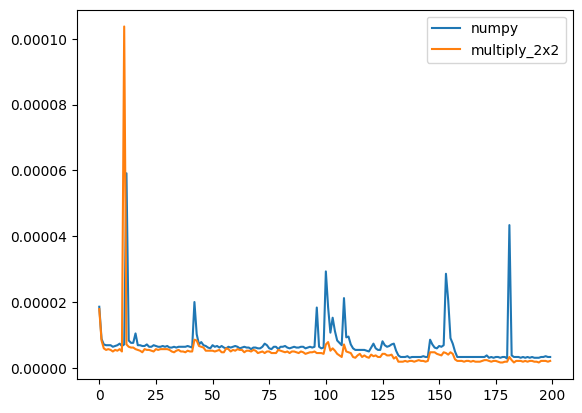

In [105]:
plt.plot(np.arange(200), np_times, label = 'numpy')
plt.plot(np.arange(200), normal_times, label = 'multiply_2x2')
plt.legend()

In [ ]:
# практически совпадает с numpy, даже чуть быстрее (в целом видим, что везде оранжевая линия ниже)
# но наш алгоритм только для матриц 2х2, а numpy написан для всех матриц (см ниже)

### Задача 3. Умножение матриц

Реализуйте умножение матриц произвольного размера и проверьте его работоспособность, сравнив выход с матричным умножением из библиотеки numpy.

Оцените асимптотику вашей функции. Постройте график времени ее работы для квадратных матриц по мере роста их размера (время как функция от $n$ при умножении двух матриц $n \times n$). Сходится ли теоретическая оценка с полученными на практике результатами? Найдите функцию вида $k n^p$ ($p$ - степень из теоретической оценки, $k$ - коэффициент), наилучшим образом подходящую под полученные измерения.

In [47]:
# работает за Theta(n3) - это наивный алгоритм :)

def multiply_nxn(n: int, matrix1: list, matrix2: list) -> list:
    out = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                out[i][j] += matrix1[i][k] * matrix2[k][j]


    return out

/tmp/ipython-input-2278986222.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


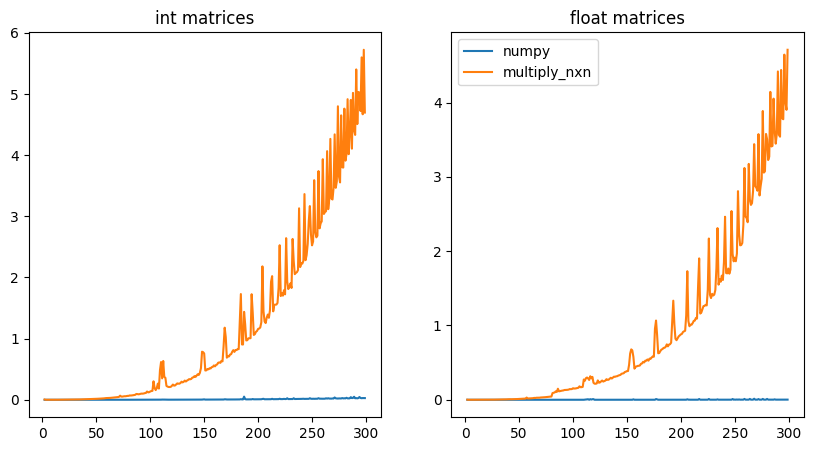

In [71]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,5))

np_times = []
normal_times = []

for n in range(2, 300):
    matrix1 = np.random.randint(-1e4, 1e4, (n,n))
    matrix2 = np.random.randint(-1e4, 1e4, (n,n))

    np_start = time.time()
    np_out = matrix1 @ matrix2
    np_end = time.time()

    my_start = time.time()
    my_out = multiply_nxn(n, matrix1.tolist(), matrix2.tolist())
    my_end = time.time()

    assert np.allclose(np_out, my_out, atol=1e-8)

    np_times.append(np_end - np_start)
    normal_times.append(my_end - my_start)

axes[0].plot(np.arange(2, 300), np_times, label = 'numpy')
axes[0].plot(np.arange(2, 300), normal_times, label = 'multiply_nxn')
axes[0].set_title('int matrices')
plt.legend()


np_times = []
normal_times = []

for n in range(2, 300):
    matrix1 = np.random.normal(loc=25, scale=50, size = (n,n))
    matrix2 = np.random.normal(loc=25, scale=50, size = (n,n))

    np_start = time.time()
    np_out = matrix1 @ matrix2
    np_end = time.time()

    my_start = time.time()
    my_out = multiply_nxn(n, matrix1.tolist(), matrix2.tolist())
    my_end = time.time()

    assert np.allclose(np_out, my_out, atol=1e-8)

    np_times.append(np_end - np_start)
    normal_times.append(my_end - my_start)

axes[1].plot(np.arange(2, 300), np_times, label = 'numpy')
axes[1].plot(np.arange(2, 300), normal_times, label = 'multiply_nxn')
axes[1].set_title('float matrices')
plt.legend()

In [ ]:
# здесь уже очевидно, что наша функция ужасна)))

In [ ]:
# так как у нас функция наивного умножения матриц, то есть Theta(n3), очевидно, что p = 3, остается подобрать k

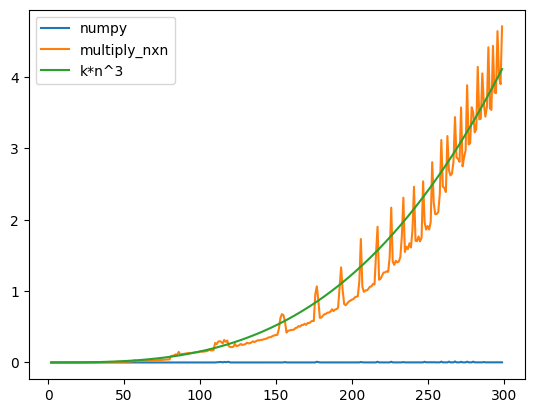

In [80]:
plt.plot(np.arange(2, 300), np_times, label = 'numpy')
plt.plot(np.arange(2, 300), normal_times, label = 'multiply_nxn')
knp = 1/(6.5*10**6) * np.arange(2, 300)**3
plt.plot(np.arange(2, 300), knp, label = 'k*n^3')
plt.legend()

In [ ]:
# в общем, k*n^p в моем случае - это n^3, с коэффициентом k сложнее, у нас не очень много данных (только первые 300 n), поэтому k примерно 1.5e-07
# но если брать больше измерений k будет расти :)

### Задача 4. Быстрый Фибоначчи

Реализуйте третий из способов нахождения чисел Фибоначчи из обсужденных на занятии (с быстрым возведением матрицы в степень). Найдите те входы, на которых второй метод (линейный) начинает работать слишком долго и запишите время, которое требуется третьему методу на обработку того же входа. Оцените время, которое заняло бы выполнение наивного (первого) алгоритма, в тысячах лет (запускать не нужно, все равно до дедлайна не досчитается).

Можно использовать реализацию второго метода из семинара, можно написать заново.

У чисел из numpy есть предельная длина, а целые числа в python обрабатываются методами длинной арифметики, так что переполнение им не грозит.

In [2]:
# naive
def naive_Fib(k):
    if k < 2:
        return k

    return naive_Fib(k - 1) + naive_Fib(k - 2)

In [11]:
# linear

# крашилось, если использовать полный массив, поэтому переписала на массив длины 3 (можно было и 2, но тут уже не суть)
def lineaar_Fib(k):
    if (k == 0):
        return 0

    Fibs = [0, 1, None]

    for i in range(2, k):
        Fibs[2] = Fibs[0] + Fibs[1]
        Fibs[0], Fibs[1] = Fibs[1], Fibs[2]

    return Fibs[2]

In [18]:
# пусть будет супер просто, вручную практически

def multiply_2x2(matrix1: list, matrix2: list) -> list:
    out = [[0, 0], [0, 0]]

    out[0][0] = matrix1[0][0] * matrix2[0][0] + matrix1[0][1] * matrix2[1][0]
    out[0][1] = matrix1[0][0] * matrix2[0][1] + matrix1[0][1] * matrix2[1][1]
    out[1][0] = matrix1[1][0] * matrix2[0][0] + matrix1[1][1] * matrix2[1][0]
    out[1][1] = matrix1[1][0] * matrix2[0][1] + matrix1[1][1] * matrix2[1][1]

    return out


In [32]:
def matrix_Fib(n: int) -> list:

    x = [[1, 1],
            [1, 0]]

    curr = x.copy()

    binary_n = str(bin(n-2))[2:]

    for b in binary_n[1:]:
        curr = multiply_2x2(curr, curr)
        if b == '1':
            curr = multiply_2x2(curr, x)

    return curr[0][0]

In [ ]:
# подбираала руками просто

In [15]:
k = int(5e6)

start = time.time()
lineaar_Fib(k)
end = time.time()
print(f'{k} Fib number, time = {end-start:.6f}')

5000000 Fib number, time = 306.606770


In [ ]:
# 300 секунд уже очень долго...

In [19]:
k = int(5e6)

start = time.time()
matrix_Fib(k)
end = time.time()
print(f'{k} Fib number, time = {end-start:.6f}')

5000000 Fib number, time = 4.421700


In [ ]:
# а вот 4 ссекунды почти ничего)

In [ ]:
# посчитаем, сколько бы считал число фибоначчи 5e6 наш наивный алгоритм

# даже в тысячах лет у меня получаются числа около 1e7 ТЫСЯЧ лет...

In [23]:

recursive_Fib = []
linear_Fib = []
matrix_Fib = []

for k in range(40):
    start = time.time()
    naive_Fib(k)
    end = time.time()
    recursive_Fib.append(end-start)


In [39]:
for k in range(10000):
    start = time.time()
    lineaar_Fib(k)
    end = time.time()
    linear_Fib.append(end-start)

In [35]:
matrix_time_Fib = []
for k in range(50000):
    start = time.time()
    matrix_Fib(k)
    end = time.time()
    matrix_time_Fib.append(end-start)

Text(0.5, 1.0, 'matrix Fibonacci')

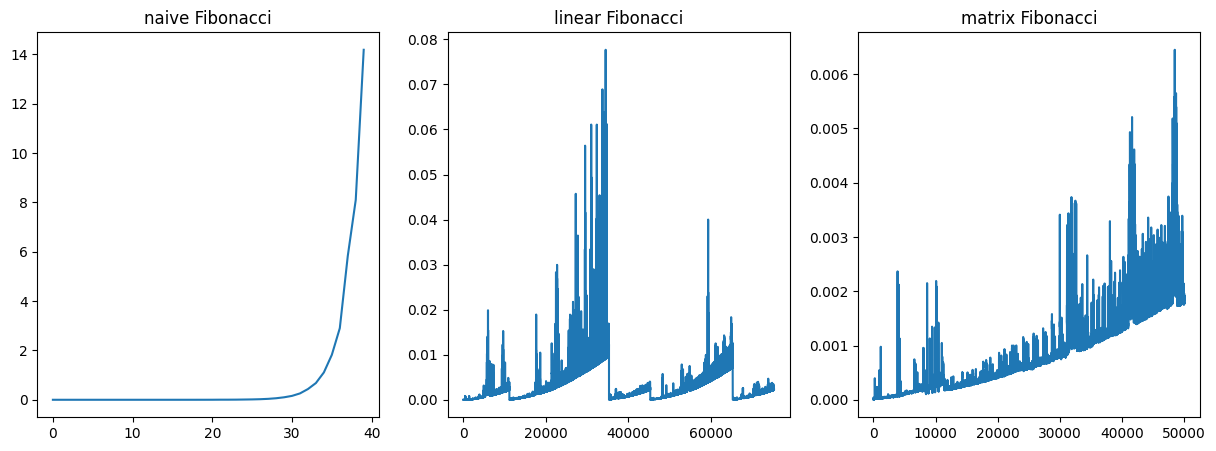

In [40]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15,5))

axes[0].plot(recursive_Fib)
axes[0].set_title('naive Fibonacci')
axes[1].plot(linear_Fib)
axes[1].set_title('linear Fibonacci')
axes[2].plot(matrix_time_Fib)
axes[2].set_title('matrix Fibonacci')

In [ ]:
# что-то линейный фибоначчи прям плох, при чем такого рода поведение наблюдается постоянно. обычно пики объясняются внутренней работой + для динамических массивов имеет место
# переполнение, но тут у нас массив всего из 3 элементов :( мб что-то с int-ами? к сожалению не могу ответить, но в лекции был график, который долго обсуждался)

### Задача 5

Найдите сложность алгоритма нахождения чисел Фибоначчи на основе сохранения предыдущих результатов, если сложение линейное по длине чисел.

In [ ]:
def lineaar_Fib(k):
    if (k == 0):
        return 0

    Fibs = [0, 1, None]

    for i in range(2, k):
        Fibs[2] = Fibs[0] + Fibs[1]
        Fibs[0], Fibs[1] = Fibs[1], Fibs[2]

    return Fibs[2]

у нас одно сложение на итерацию

```
Fibs[2] = Fibs[0] + Fibs[1]
```

так как сложение линейно, оценим длину битовой записи числа

$$len_{bit} = {\log_2n}$$

Возьмем формулу для n-ого числа Фибоначчи

$${F_n} = {\frac{φ^n}{\sqrt{5}}}$$

Теперь попробуем взять логарифм

$${\log_2\frac{φ^n}{\sqrt{5}} \leq \log_2\frac{2^n}{\sqrt{5}} \leq \log_2{2^n} = n}$$

Останемся с оценкой того, что длина числа фибоначчи оценивается сверху его номером n.


Попробуем оценить сумму для поиска n чисел:

$${∑_0^n \log_2 F_n \leq ∑_0^nn = O(n^2)} $$

Ответ: $O(N^2)$






*график у нас так и выглядел - рассуждали, что он похож на параболу. с учетом допущений, возможно это и правда*